# Análisis y Modelamiento de Datos: Riesgo de Incendios Forestales en Ecuador
### Un reporte visual interactivo bajo la metodología y diseño editorial de **Latinometrics**

Este estudio analiza las correlaciones climatológicas, el comportamiento estacional y los factores espaciales de los incendios forestales en Ecuador (2012-2026). Los hallazgos presentados en este notebook sirven como **justificación física directa** para la selección de las variables de entrada utilizadas en nuestros modelos de Machine Learning (XGBoost y K-Means).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
import warnings
warnings.filterwarnings('ignore')

# --- PALETA DE COLORES OFICIAL DE LATINOMETRICS ---
LM_NAVY = '#0F172A'      # Azul noche oscuro para títulos y texto principal
LM_RED = '#E11D48'       # Rojo carmín para incendios y peligro
LM_BLUE = '#2563EB'      # Azul rey para lluvia y humedad
LM_GREEN = '#059669'     # Verde bosque para vegetación (NDVI)
LM_ORANGE = '#EA580C'    # Naranja cálido para temperatura y viento
LM_GRID = '#F1F5F9'      # Gris neutro muy claro para cuadrículas de fondo
LM_TEXT_MUTED = '#64748B'# Gris medio para subtítulos y anotaciones secundarias

# Configuración visual de los gráficos para evitar cualquier corte o solapamiento
plt.rcParams['figure.facecolor'] = '#FFFFFF'
plt.rcParams['axes.facecolor'] = '#FFFFFF'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['text.color'] = LM_NAVY
plt.rcParams['axes.labelcolor'] = LM_NAVY
plt.rcParams['xtick.color'] = LM_TEXT_MUTED
plt.rcParams['ytick.color'] = LM_TEXT_MUTED
plt.rcParams['grid.color'] = LM_GRID

## 1. Conexión y Consumo de Datos desde SQL Server
Consumimos la base de datos limpia de SQL Server para extraer los datos unificados en 3FN.

In [2]:
CONN_STR = "mssql+pyodbc://LUIS/IncendiosForestalesEC?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
engine = create_engine(CONN_STR)

df = pd.read_sql("SELECT * FROM vw_DatosUnificados ORDER BY fecha, id_ciudad", con=engine)
df['fecha'] = pd.to_datetime(df['fecha'])
df['mes'] = df['fecha'].dt.month
df['anio'] = df['fecha'].dt.year

print(f"Base de datos cargada: {len(df):,} días climatológicos con cobertura vegetal e incendios registrados.")

Base de datos cargada: 21,100 días climatológicos con cobertura vegetal e incendios registrados.


## 2. Temporalidad: El Momento Crítico del Fuego
Analizamos la distribución anual de fuegos para identificar en qué época del año se dispara el peligro de incendios.

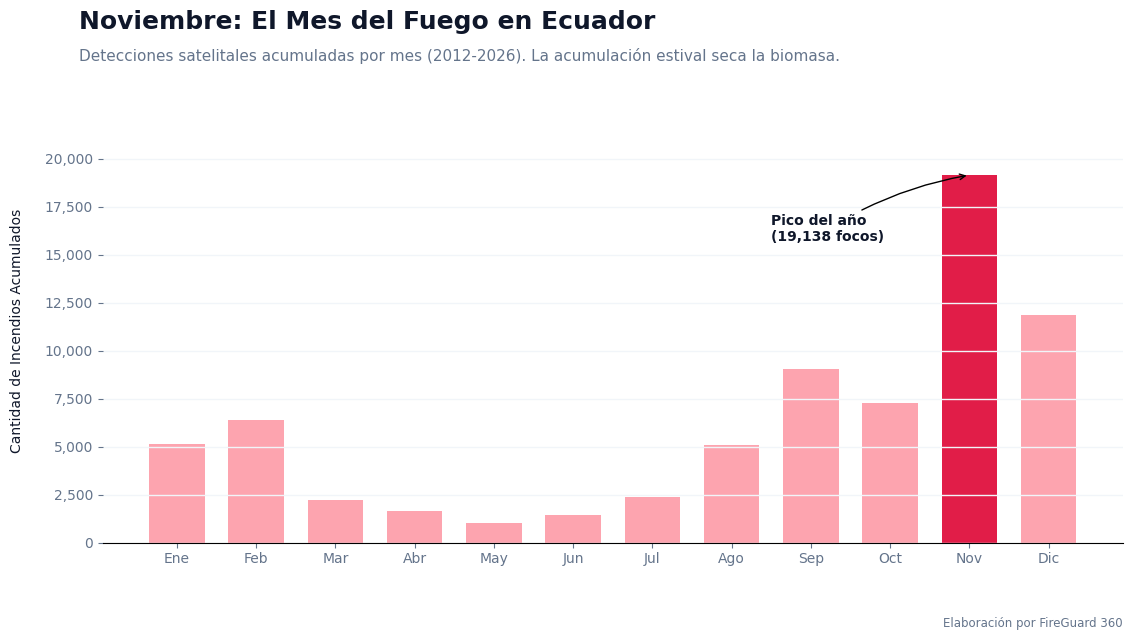

In [3]:
df_temporal = df.groupby('mes')['conteo_incendios'].sum().reset_index()
meses_es = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
df_temporal['nombre_mes'] = meses_es

fig, ax = plt.subplots(figsize=(12, 6.5))
bars = ax.bar(df_temporal['nombre_mes'], df_temporal['conteo_incendios'], 
              color=[LM_RED if x == 'Nov' else '#FDA4AF' for x in df_temporal['nombre_mes']], 
              width=0.7)

# Estilo Latinometrics (Despine & Grid)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.yaxis.grid(True, linestyle='-', linewidth=1, color=LM_GRID)

# Títulos mediante fig.text con coordenadas explícitas para evitar solapamiento y recortes
fig.text(0.08, 0.94, "Noviembre: El Mes del Fuego en Ecuador", fontsize=18, fontweight='bold', color=LM_NAVY)
fig.text(0.08, 0.89, "Detecciones satelitales acumuladas por mes (2012-2026). La acumulación estival seca la biomasa.", fontsize=11, color=LM_TEXT_MUTED)

# Créditos / Leyenda en la parte inferior
fig.text(0.95, 0.02, "Elaboración por FireGuard 360", fontsize=8.5, color=LM_TEXT_MUTED, ha='right')

# Anotación de datos exacta
pico_val = df_temporal.loc[df_temporal['nombre_mes'] == 'Nov', 'conteo_incendios'].values[0]
ax.annotate(f'Pico del año\n({pico_val:,} focos)', 
            xy=(10, pico_val), xytext=(7.5, pico_val * 0.82),
            arrowprops=dict(facecolor=LM_NAVY, arrowstyle="->", connectionstyle="arc3,rad=-0.1"),
            fontsize=10, fontweight='bold', color=LM_NAVY)

ax.set_ylim(0, pico_val * 1.15)
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.ylabel("Cantidad de Incendios Acumulados", fontsize=10, labelpad=15)
fig.subplots_adjust(top=0.80, bottom=0.15, left=0.10, right=0.95)
plt.show()

## 3. Distribución Geográfica y Regional
Comparamos la presencia del fuego en la Costa (Guayaquil) frente a la Sierra (Quito, Cuenca y Riobamba).

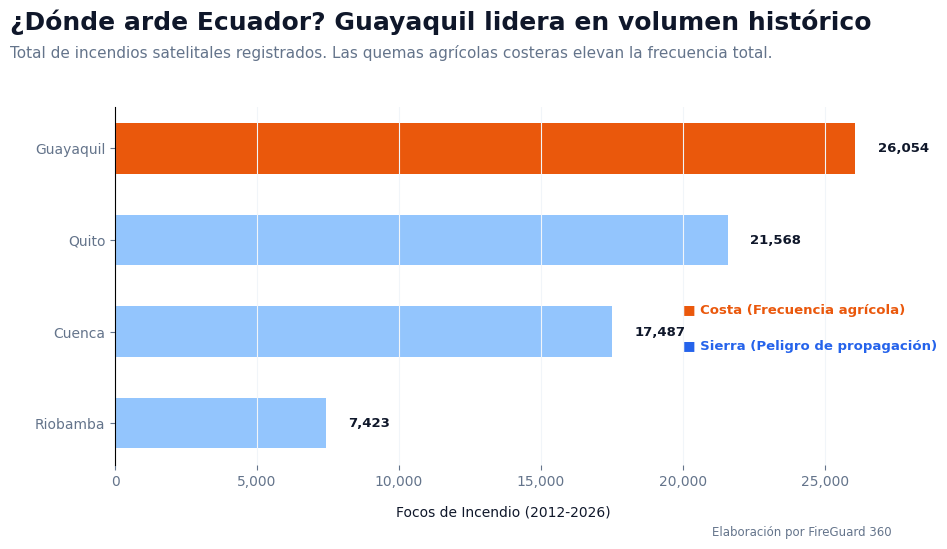

In [4]:
df_ciudades = df.groupby(['ciudad_nombre', 'ciudad_region'])['conteo_incendios'].sum().reset_index()
df_ciudades = df_ciudades.sort_values(by='conteo_incendios', ascending=True)

fig, ax = plt.subplots(figsize=(10.5, 5.5))
colors = [LM_ORANGE if reg == 'Costa' else '#93C5FD' for reg in df_ciudades['ciudad_region']]
bars = ax.barh(df_ciudades['ciudad_nombre'], df_ciudades['conteo_incendios'], color=colors, height=0.55)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.xaxis.grid(True, linestyle='-', color=LM_GRID)
ax.yaxis.grid(False)

# Títulos alineados
fig.text(0.08, 0.94, "¿Dónde arde Ecuador? Guayaquil lidera en volumen histórico", fontsize=18, fontweight='bold', color=LM_NAVY)
fig.text(0.08, 0.89, "Total de incendios satelitales registrados. Las quemas agrícolas costeras elevan la frecuencia total.", fontsize=11, color=LM_TEXT_MUTED)

# Créditos / Leyenda en la parte inferior
fig.text(0.92, 0.02, "Elaboración por FireGuard 360", fontsize=8.5, color=LM_TEXT_MUTED, ha='right')

# Valores al final de cada barra
for bar in bars:
    width = bar.get_width()
    ax.text(width + 800, bar.get_y() + bar.get_height()/2, f'{int(width):,}', 
            va='center', ha='left', fontsize=9.5, fontweight='bold', color=LM_NAVY)

# Leyenda manual integrada
ax.text(20000, 1.2, "■ Costa (Frecuencia agrícola)", color=LM_ORANGE, fontweight='bold', fontsize=9.5)
ax.text(20000, 0.8, "■ Sierra (Peligro de propagación)", color='#2563EB', fontweight='bold', fontsize=9.5)

ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.xlabel("Focos de Incendio (2012-2026)", fontsize=10, labelpad=12)
fig.subplots_adjust(top=0.80, bottom=0.15, left=0.18, right=0.92)
plt.show()

## 4. El Gran Detonante: Temperatura Máxima vs. Precipitación
A continuación, cruzamos la línea de temperaturas máximas del aire con la precipitación promedio mensual. Se observa que el calor extremo coincide con la sequía estival de la Sierra andina.

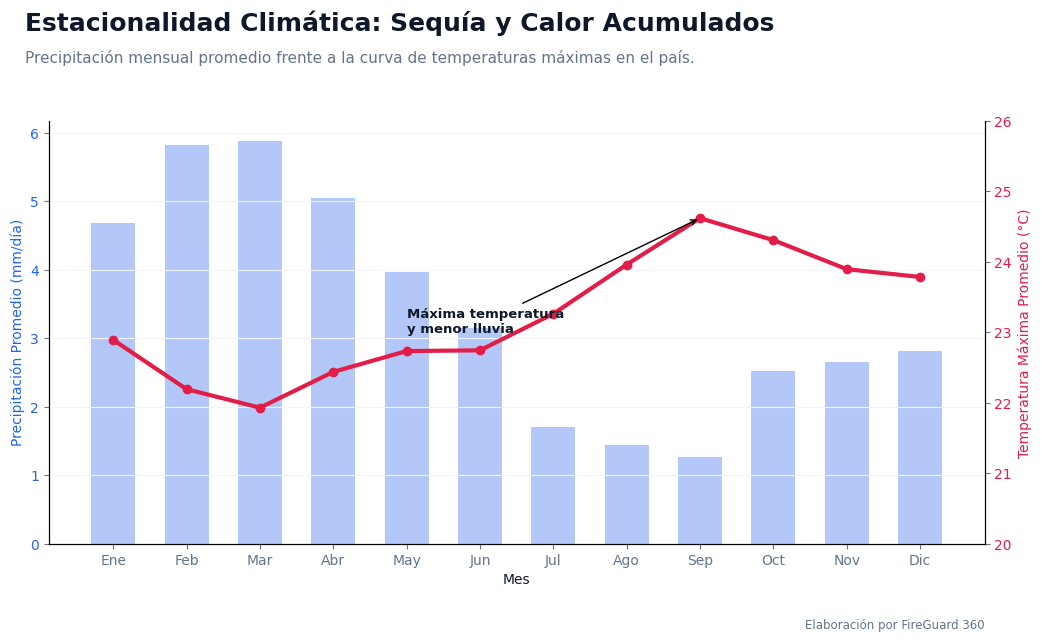

In [5]:
df_clima_m = df.groupby('mes').agg({
    'temperatura_max': 'mean',
    'precipitacion': 'mean'
}).reset_index()
df_clima_m['nombre_mes'] = meses_es

fig, ax1 = plt.subplots(figsize=(12, 6.5))

# Eje izquierdo: Precipitación (Lluvias)
ax1.set_xlabel('Mes')
ax1.set_ylabel('Precipitación Promedio (mm/día)', color=LM_BLUE)
bars = ax1.bar(df_clima_m['nombre_mes'], df_clima_m['precipitacion'], color=LM_BLUE, alpha=0.35, width=0.6, label='Lluvia')
ax1.tick_params(axis='y', labelcolor=LM_BLUE)
ax1.yaxis.grid(True, linestyle='-', color=LM_GRID)

# Eje derecho: Temperatura Máxima
ax2 = ax1.twinx()
ax2.set_ylabel('Temperatura Máxima Promedio (°C)', color=LM_RED)
line = ax2.plot(df_clima_m['nombre_mes'], df_clima_m['temperatura_max'], color=LM_RED, linewidth=3, marker='o', label='Temp. Máx')
ax2.tick_params(axis='y', labelcolor=LM_RED)
ax2.set_ylim(20, 26)

ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

# Títulos seguros
fig.text(0.08, 0.94, "Estacionalidad Climática: Sequía y Calor Acumulados", fontsize=18, fontweight='bold', color=LM_NAVY)
fig.text(0.08, 0.89, "Precipitación mensual promedio frente a la curva de temperaturas máximas en el país.", fontsize=11, color=LM_TEXT_MUTED)

# Créditos / Leyenda en la parte inferior
fig.text(0.88, 0.02, "Elaboración por FireGuard 360", fontsize=8.5, color=LM_TEXT_MUTED, ha='right')

ax2.annotate('Máxima temperatura\ny menor lluvia', xy=(8, 24.62), xytext=(4.0, 23.0), 
             arrowprops=dict(facecolor=LM_NAVY, arrowstyle="->"), 
             color=LM_NAVY, fontsize=9.5, fontweight='bold')

fig.subplots_adjust(top=0.80, bottom=0.15, left=0.10, right=0.88)
plt.show()

## 5. El Factor del Viento: Propagación y Aceleración
El viento es un factor clave en los modelos supervisados de incendios forestales. No solo propaga el fuego, sino que aporta oxígeno acelerando la combustión.

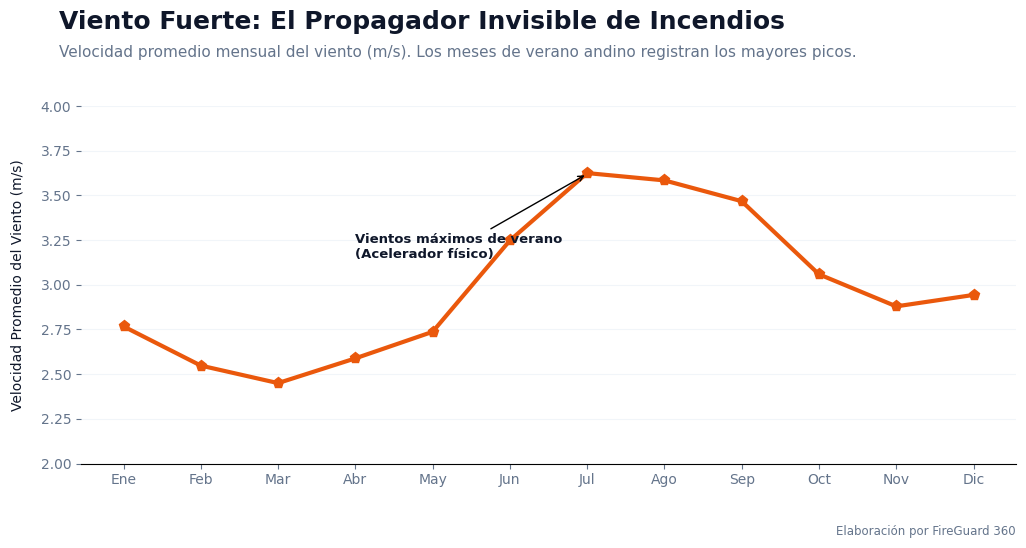

In [6]:
df_viento = df.groupby('mes')['velocidad_viento'].mean().reset_index()
df_viento['nombre_mes'] = meses_es

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(df_viento['nombre_mes'], df_viento['velocidad_viento'], color=LM_ORANGE, linewidth=3, marker='p', markersize=8)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.yaxis.grid(True, linestyle='-', color=LM_GRID)
ax.set_ylim(2.0, 4.0)

# Títulos seguros
fig.text(0.08, 0.94, "Viento Fuerte: El Propagador Invisible de Incendios", fontsize=18, fontweight='bold', color=LM_NAVY)
fig.text(0.08, 0.89, "Velocidad promedio mensual del viento (m/s). Los meses de verano andino registran los mayores picos.", fontsize=11, color=LM_TEXT_MUTED)

# Créditos / Leyenda en la parte inferior
fig.text(0.95, 0.02, "Elaboración por FireGuard 360", fontsize=8.5, color=LM_TEXT_MUTED, ha='right')

ax.annotate('Vientos máximos de verano\n(Acelerador físico)', xy=(6, 3.62), xytext=(3.0, 3.15), 
             arrowprops=dict(facecolor=LM_NAVY, arrowstyle="->"), 
             color=LM_NAVY, fontsize=9.5, fontweight='bold')

plt.ylabel("Velocidad Promedio del Viento (m/s)", fontsize=10, labelpad=12)
fig.subplots_adjust(top=0.80, bottom=0.15, left=0.10, right=0.95)
plt.show()

## 6. La Humedad del Aire: El Escudo Natural
La humedad actúa como un escudo natural que absorbe calor antes de que la vegetación entre en ignición. Cuando la humedad cae por debajo del 60%, el escudo desaparece.

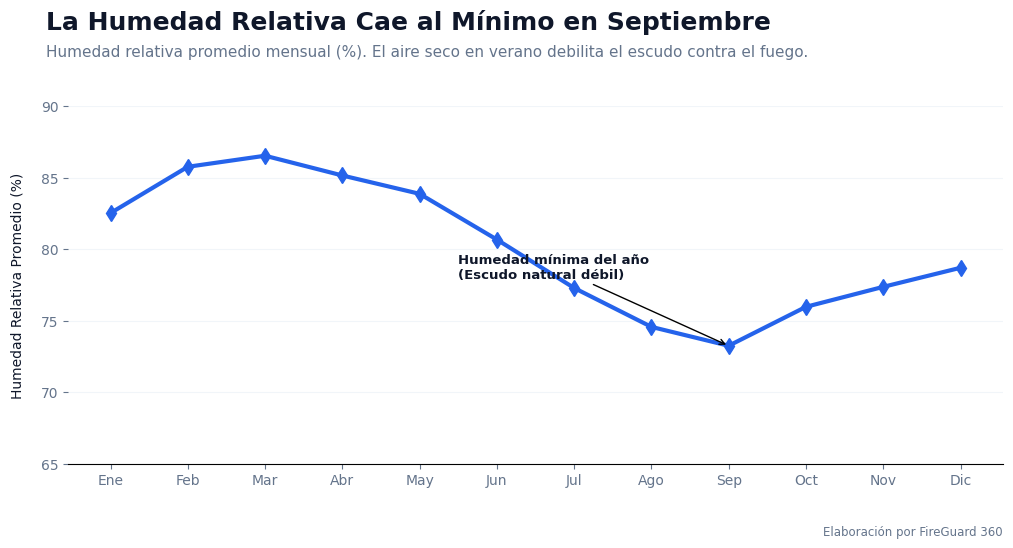

In [7]:
df_humedad = df.groupby('mes')['humedad_relativa'].mean().reset_index()
df_humedad['nombre_mes'] = meses_es

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(df_humedad['nombre_mes'], df_humedad['humedad_relativa'], color=LM_BLUE, linewidth=3, marker='d', markersize=8)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.yaxis.grid(True, linestyle='-', color=LM_GRID)
ax.set_ylim(65, 90)

# Títulos seguros
fig.text(0.08, 0.94, "La Humedad Relativa Cae al Mínimo en Septiembre", fontsize=18, fontweight='bold', color=LM_NAVY)
fig.text(0.08, 0.89, "Humedad relativa promedio mensual (%). El aire seco en verano debilita el escudo contra el fuego.", fontsize=11, color=LM_TEXT_MUTED)

# Créditos / Leyenda en la parte inferior
fig.text(0.95, 0.02, "Elaboración por FireGuard 360", fontsize=8.5, color=LM_TEXT_MUTED, ha='right')

ax.annotate('Humedad mínima del año\n(Escudo natural débil)', xy=(8, 73.23), xytext=(4.5, 78.0), 
             arrowprops=dict(facecolor=LM_NAVY, arrowstyle="->"), 
             color=LM_NAVY, fontsize=9.5, fontweight='bold')

plt.ylabel("Humedad Relativa Promedio (%)", fontsize=10, labelpad=12)
fig.subplots_adjust(top=0.80, bottom=0.15, left=0.10, right=0.95)
plt.show()

## 7. Vegetación como Combustible Forestal (NDVI)
El NDVI desciende durante la estación seca, revelando cómo la vegetación pierde verdor, pasa a marchitarse y se transforma en combustible listo para arder.

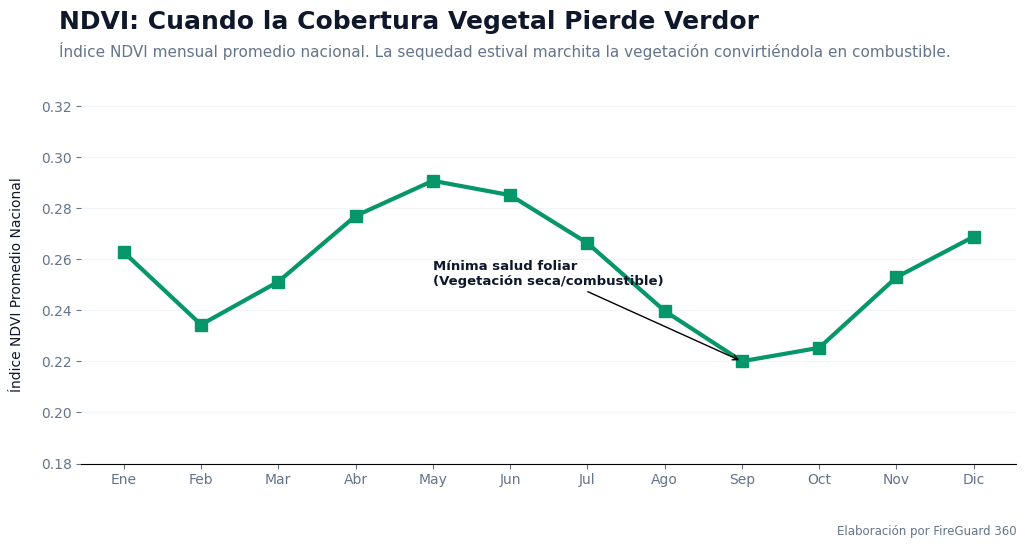

In [8]:
df_ndvi = df.groupby('mes')['ndvi'].mean().reset_index()
df_ndvi['nombre_mes'] = meses_es

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(df_ndvi['nombre_mes'], df_ndvi['ndvi'], color=LM_GREEN, linewidth=3, marker='s', markersize=8)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.yaxis.grid(True, linestyle='-', color=LM_GRID)
ax.set_ylim(0.18, 0.32)

# Títulos seguros
fig.text(0.08, 0.94, "NDVI: Cuando la Cobertura Vegetal Pierde Verdor", fontsize=18, fontweight='bold', color=LM_NAVY)
fig.text(0.08, 0.89, "Índice NDVI mensual promedio nacional. La sequedad estival marchita la vegetación convirtiéndola en combustible.", fontsize=11, color=LM_TEXT_MUTED)

# Créditos / Leyenda en la parte inferior
fig.text(0.95, 0.02, "Elaboración por FireGuard 360", fontsize=8.5, color=LM_TEXT_MUTED, ha='right')

ax.annotate('Mínima salud foliar\n(Vegetación seca/combustible)', xy=(8, 0.220), xytext=(4.0, 0.25), 
             arrowprops=dict(facecolor=LM_NAVY, arrowstyle="->"), 
             color=LM_NAVY, fontsize=9.5, fontweight='bold')

plt.ylabel("Índice NDVI Promedio Nacional", fontsize=10, labelpad=12)
fig.subplots_adjust(top=0.80, bottom=0.15, left=0.10, right=0.95)
plt.show()